# Morison equation

Force on a submerged body in oscillatory flow can be split into the following terms
$$
F = F_{D} + F_{FK} + F_{AM}
$$

$F_{D}$ = Drag due to viscous effects <br>
$F_{FK}$ = Froude-Krylov force, due to the pressure gradient under the oscillatory flow. <br>
$F_{AM}$ = Hydrodynamic Mass / Added Mass, due to the acceleration of surrounding fluid.

For a cylindrical body <br>
$F_{D} =  \frac{1}{2} C_d \times \rho D u |u| $ <br>
$F_{FK} = \rho A \dot{u}$ <br>
$F_{AM} = C_m \times \rho A \dot{u}$

$F =  \frac{1}{2} C_d \times \rho D u |u| + (1+C_m) \rho A \dot{u}$ <br>
$C_I = 1 + C_M$

Note that $F_D$ is nonlinear. Therefore, it will not be possible to linearly superimpose the force due to various wave components.


## Install MHKiT for generating spectrum

We use the following package to generate the JONSWAP spectrum

https://mhkit-software.github.io/MHKiT/index.html

Install it using `pip`
Ignore warnings

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Define constants

## Define cylindrical structures

## Generating wave spectrum using MHKiT

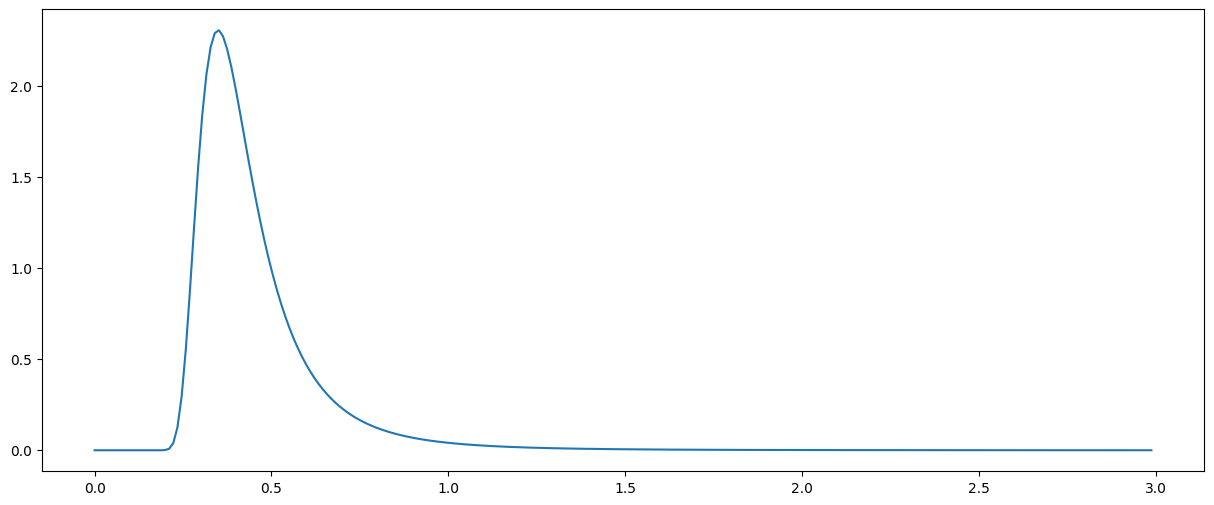

### Get amplitude spectrum from power spectral density function

Definition of single-sided power spectral density function is given by
$$
\sum_f^{f+\Delta f} \frac{1}{2} a_n^2 = S_n(f) \Delta f \quad
$$
PSDF has a unit of $m^2 \cdot s$

The single-sided amplitude spectrum is given by 
$$
a_n(f) = \sqrt{2 S_n(f) \Delta f}
$$

Here `S.args`$= \omega$ and `S.data`= Spectral density value

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Wout-\AppData\Local\Temp\ipykernel_13032\4292758610.py:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\Wout-\AppData\Local\Temp\ipykernel_13032\4292758610.py:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not

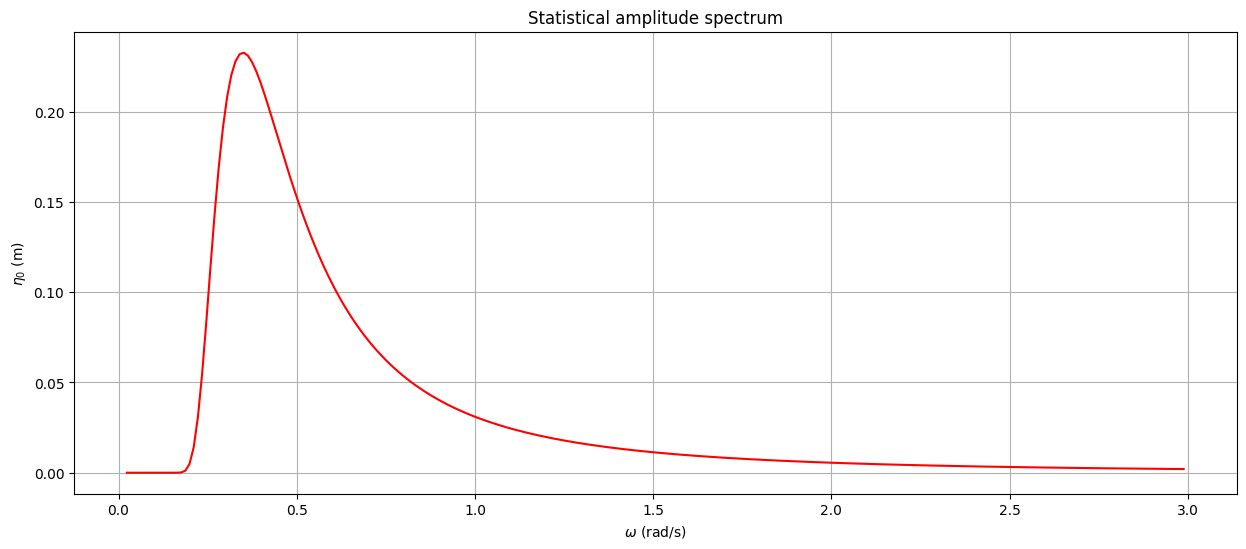

## Define Case

We use `LinearWave2D` class from `LinearWave` package for defining the linear wave and the associated particle velocity, acceleration and pressure fields.

The linear wave theory only calculate the pressure and velocities for $z<=0$. <br> In order to calculate the values for $z>0$ we use

- For Pressure: Taylor series expansion, limited to first order
- For Velocities: Wheeler stretching [link](https://www.orcina.com/webhelp/OrcaFlex/Content/html/Waves,Kinematicstretching.htm#:~:text=Wheeler%20stretching,at%20the%20instantaneous%20water%20surface.)

We initiate `LineaerWave` object using amplitudes from JONSWAP spectrum and random phase. This will be used for obtaining the elevation, velocity and acceleration time-series for calculating the forces.

### Documentation of `LinearWave2D`

We have two classes

- `LinearWave2D`: Class to define wave in shallow water
    - `wv = LinearWave2D(rhoW, g, d, T, H)`
    - `rhoW`: Density of water
    - `g`: acceleration due to gravity
    - `d`: still-water depth
    - `T`: Wave time-period
    - `H`: Wave-height

- `LinearWaveDeep2D`: Class to define wave in deep water
    - `wv = LinearWave2D(rhoW, g, T, H)`
    - `rhoW`: Density of water
    - `g`: acceleration due to gravity
    - `T`: Wave time-period
    - `H`: Wave-height


Location in 2D space is defined as `(x,z)`
The time instant is `t`

- `wv.waveElevation(t,x)` : Wave elevation at a given x
- `wv.pressureTot(t,x,z)` : Total pressure (static + dynamic pressure)
- `wv.pressureDyn(t,x,z)` : Dynamic pressure
- `wv.particleVelPoi(t,x,z)` : Wave particle vel at (x,z) at time-instant t
- `wv.particleAccPoi(t,x,z)` : Wave particle acceleration at (x,z) at time-instant t
- `wv.particleVelMax(t,x,z)` : Maximum of wave particle vel at location (x,z)
- `wv.particleAccMax(t,x,z)` : Maximum of wave particle acceleration at location (x,z)

Here `wv` can be an object of `LinearWave2D` or `LinearWaveDeep2D`

## Calculate elevation, velocities and acceleration from spectrum

[0. 0. 0. ... 0. 0. 0.] [0.3881513  0.38624089 0.38367452 ... 0.04680856 0.04550755 0.04431942] [-0.07566047 -0.09106618 -0.10649072 ... -0.06946335 -0.06923338
 -0.06901753] [0.39545662 0.39683129 0.39817887 ... 0.08376275 0.08285046 0.08202214] [-0.01585464 -0.02236941 -0.02897113 ... -0.01358668 -0.01243927
 -0.01133037] [-0.15386383 -0.15420115 -0.1542391  ...  0.00233597  0.00224616
  0.00205403]
1200 dit is de lengte van vx_t
Elapsed time =  8.111685752868652  s


<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:23: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:23: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Wout-\AppData\Local\Temp\ipykernel_13032\2442311115.py:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.ylabel('$\eta$ (m)')
C:\Users\Wout-\AppData\Local\Temp\ipykernel_13032\2442311115.py:23: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not wo

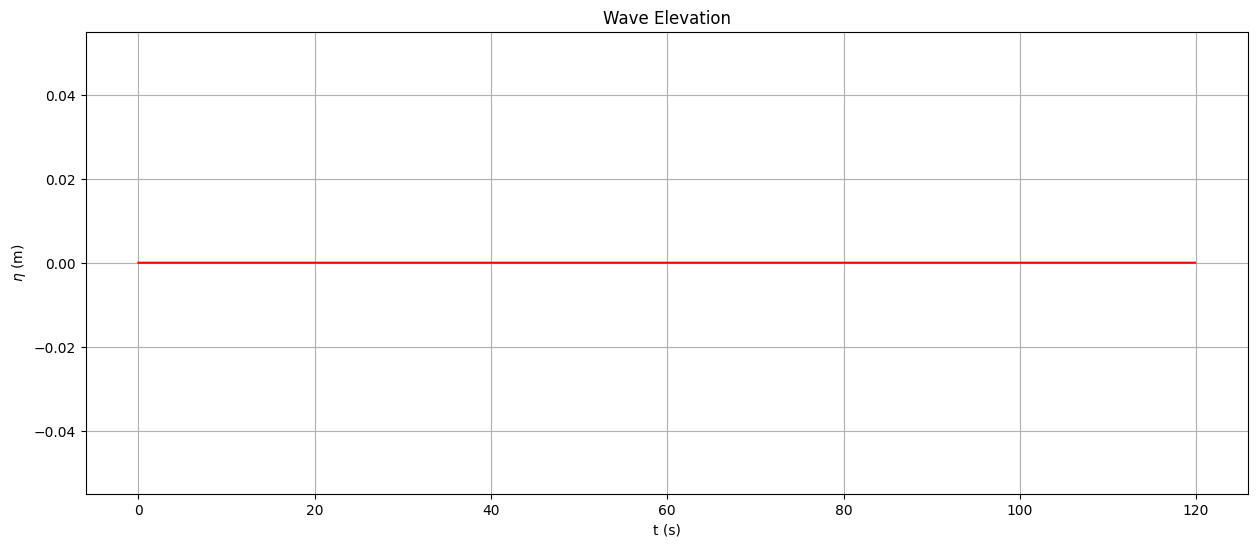

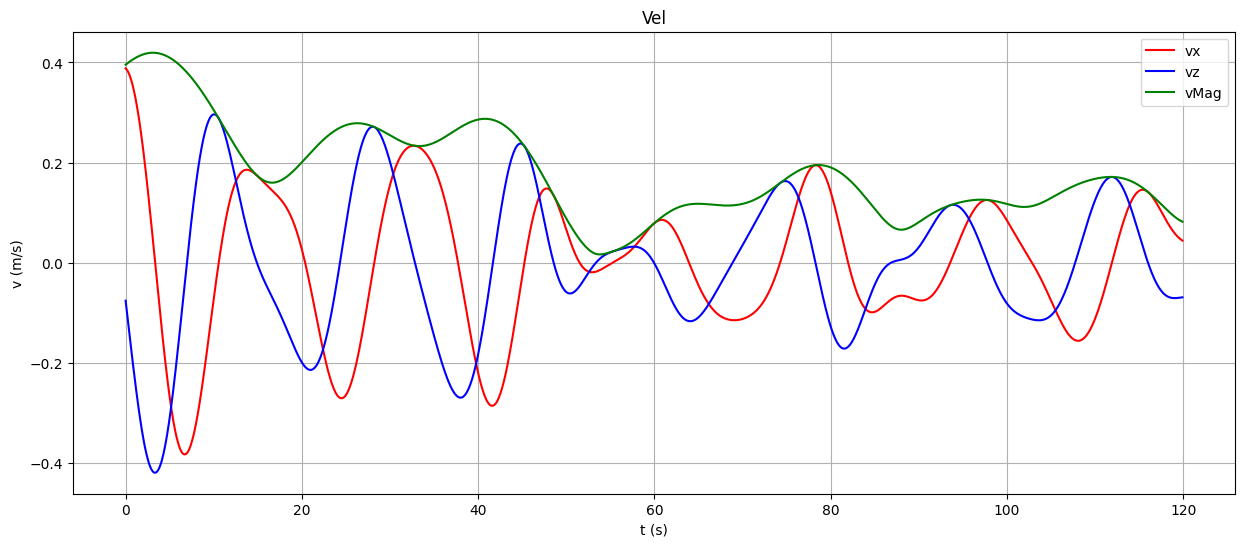

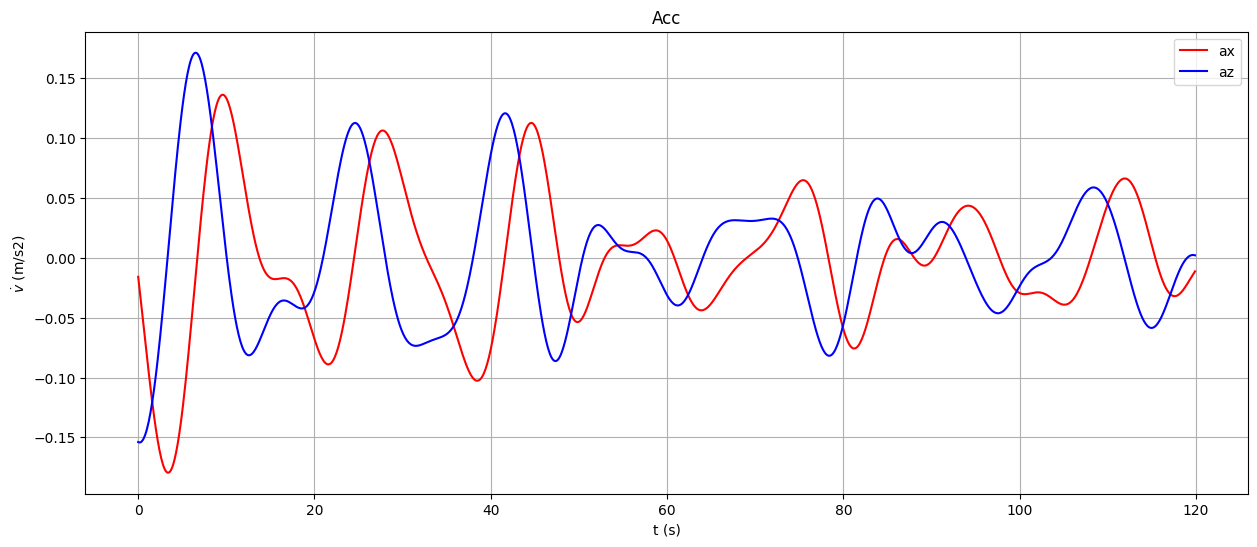

## Calculate force amplitude using particle acceleration

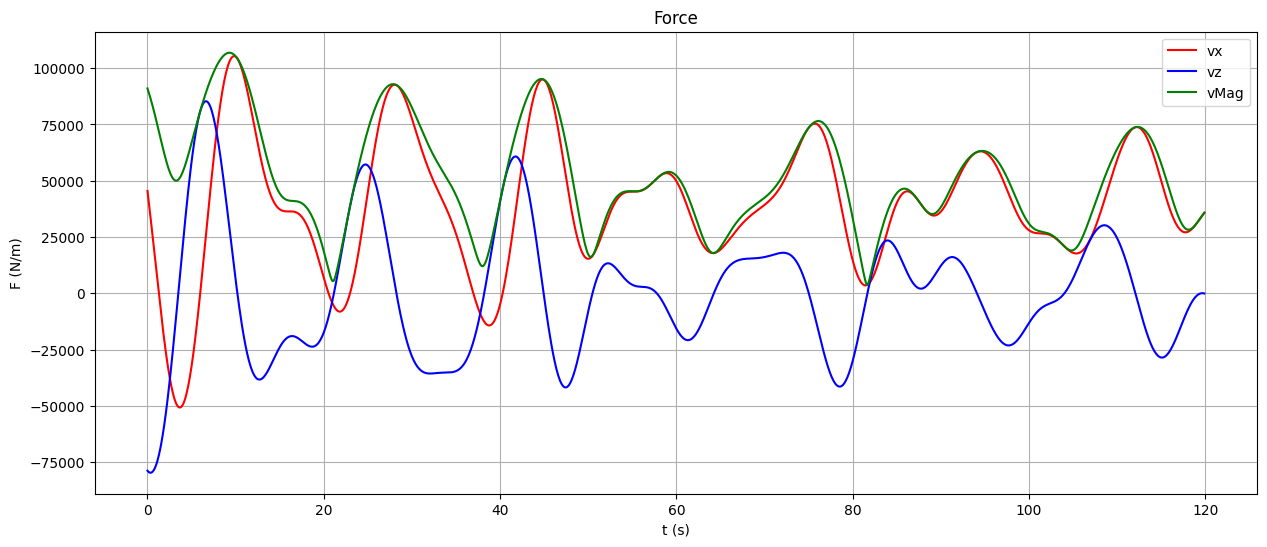

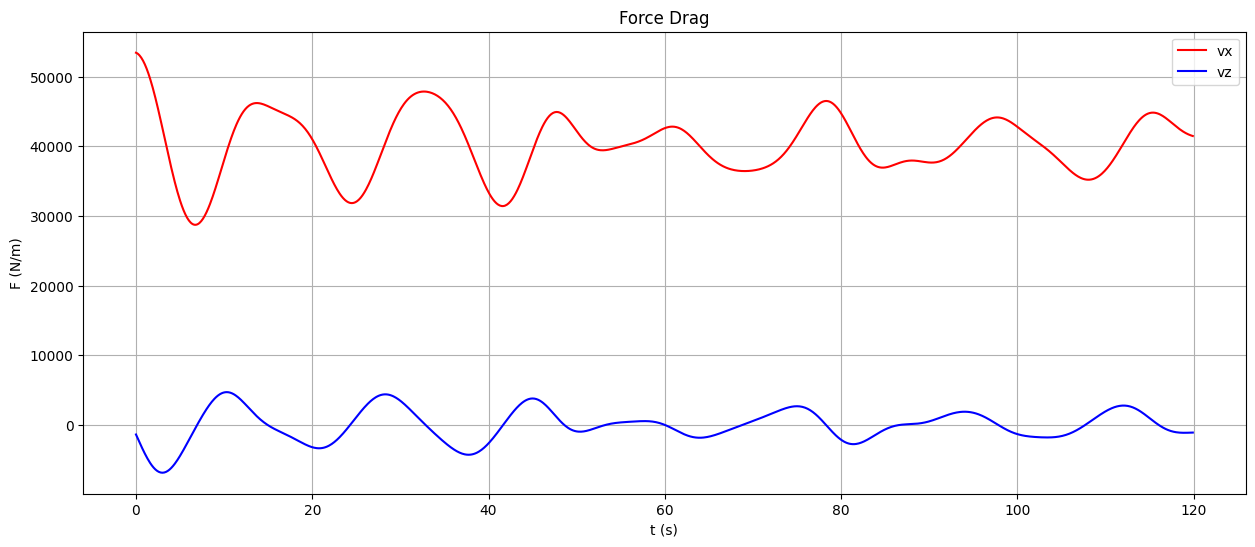

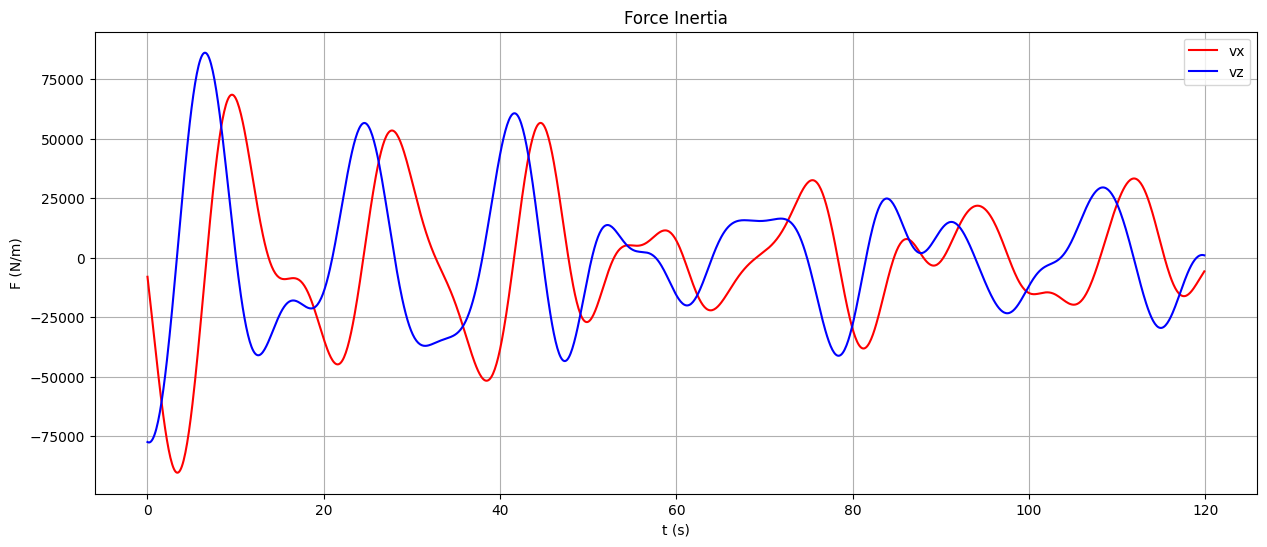